# Auto Insurance Pure Premium Modeling - Refined Case Study

This notebook keeps the original project purpose: estimate personal auto **pure premium** through separate frequency and severity models, compare an actuarial GLM baseline with a GBM challenger, and translate the results into pricing diagnostics and rating relativities.

The workflow is deliberately narrower and more rigorous than the original version:

- frequency and severity use the same positive-paid-claim definition;
- capped severity receives an explicit training-derived tail provision;
- train, validation, and test sets have separate roles;
- feature definitions are stable and scoring-ready;
- model selection uses validation deviance rather than test-set A/E;
- the final narrative is calculated from current results rather than hard-coded.

The output remains a pure-premium indication, not a final customer premium.


## 0. Setup


In [1]:
from pathlib import Path
import os
import warnings

os.environ.setdefault("LOKY_MAX_CPU_COUNT", "4")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import mean_gamma_deviance, mean_tweedie_deviance
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", "{:,.4f}".format)
sns.set_theme(style="whitegrid", context="notebook")

RANDOM_STATE = 42

# Locate the workspace without hard-coding a user-specific project path.
def find_workspace_root(start=None):
    start = Path.cwd() if start is None else Path(start)
    for candidate in [start, *start.parents]:
        freq_path = candidate / "data" / "auto_pricing" / "fremtpl" / "fremtpl2freq.csv"
        framework_path = candidate / "projects" / "auto_pricing" / "project_framework.md"
        if freq_path.exists() and framework_path.exists():
            return candidate
    raise FileNotFoundError("Run this notebook from inside the auto_pricing workspace.")

WORKSPACE_ROOT = find_workspace_root()
DATA_DIR = WORKSPACE_ROOT / "data" / "auto_pricing" / "fremtpl"
FREQ_PATH = DATA_DIR / "fremtpl2freq.csv"
SEV_PATH = DATA_DIR / "fremtpl2sev.csv"

print(f"Workspace: {WORKSPACE_ROOT}")


Workspace: C:\Users\lvlhh\OneDrive\Transfer_pending\PC_projects


## 1. Load, Validate, and Reconcile Claims

`ClaimNb` counts reported claims, while the severity file contains positive payment records. The refined model uses the number of matched positive payments as its frequency target so that frequency and severity multiply to the same loss definition.


In [2]:
# Load policy-level frequency data and claim-level payment data.
freq = pd.read_csv(FREQ_PATH)
sev = pd.read_csv(SEV_PATH)

# Fail early if the downloaded files do not match the expected schema.
required_freq = {"IDpol", "ClaimNb", "Exposure", "Area", "VehPower", "VehAge", "DrivAge", "BonusMalus", "VehBrand", "VehGas", "Density", "Region"}
required_sev = {"IDpol", "ClaimAmount"}
assert required_freq.issubset(freq.columns), required_freq - set(freq.columns)
assert required_sev.issubset(sev.columns), required_sev - set(sev.columns)

# Standardize join keys and categorical labels before reconciliation.
freq["IDpol"] = freq["IDpol"].astype("int64")
sev["IDpol"] = sev["IDpol"].astype("int64")
for col in ["Area", "VehBrand", "VehGas", "Region"]:
    freq[col] = freq[col].astype(str).str.replace("'", "", regex=False).str.strip()

# Keep records that can contribute to exposure-based loss cost.
freq = freq.loc[freq["Exposure"] > 0].copy()
sev = sev.loc[sev["ClaimAmount"] > 0].copy()

# Separate payment rows that cannot be linked to a policy record.
matched_mask = sev["IDpol"].isin(freq["IDpol"])
sev_matched = sev.loc[matched_mask].copy()
sev_unmatched = sev.loc[~matched_mask].copy()

# Aggregate positive payments to the policy level used by the pricing model.
paid_agg = (
    sev_matched.groupby("IDpol", as_index=False)
    .agg(
        PaidClaimNb=("ClaimAmount", "size"),
        TotalClaimAmount=("ClaimAmount", "sum"),
        MeanPositivePayment=("ClaimAmount", "mean"),
        MaxPositivePayment=("ClaimAmount", "max"),
    )
)

# Policies without a matched payment remain valid zero-paid-claim records.
pricing = freq.merge(paid_agg, on="IDpol", how="left")
fill_cols = ["PaidClaimNb", "TotalClaimAmount", "MeanPositivePayment", "MaxPositivePayment"]
pricing[fill_cols] = pricing[fill_cols].fillna(0)
pricing["PaidClaimNb"] = pricing["PaidClaimNb"].astype(int)
pricing["ObservedPaidFrequency"] = pricing["PaidClaimNb"] / pricing["Exposure"]
pricing["ObservedPurePremium"] = pricing["TotalClaimAmount"] / pricing["Exposure"]

reconciliation = pd.DataFrame({
    "metric": [
        "policy records", "exposure", "reported claims in frequency file",
        "positive payment records", "matched positive payments",
        "unmatched positive payments", "unmatched paid loss",
        "policies with exposure above one", "maximum exposure",
    ],
    "value": [
        len(pricing), pricing["Exposure"].sum(), pricing["ClaimNb"].sum(),
        len(sev), len(sev_matched), len(sev_unmatched),
        sev_unmatched["ClaimAmount"].sum(), (pricing["Exposure"] > 1).sum(),
        pricing["Exposure"].max(),
    ],
})
reconciliation


,metric,value
0,policy records,"678,013.0000"
1,exposure,"358,499.4455"
2,reported claims in frequency file,"36,102.0000"
3,positive payment records,"26,639.0000"
4,matched positive payments,"26,444.0000"
5,unmatched positive payments,195.0000
6,unmatched paid loss,"788,714.1800"
7,policies with exposure above one,"1,224.0000"
8,maximum exposure,2.0100


## 2. Stable Rating Features

Fixed actuarial bands support transparent GLM relativities. The GBM later uses only nominal categories and capped continuous variables, avoiding duplicate raw-and-banded predictors and batch-dependent quantile bands.


In [3]:
def add_rating_features(df):
    out = df.copy()
    # Cap sparse extremes to keep rating factors stable in small segments.
    out["VehPowerCapped"] = out["VehPower"].clip(4, 15).astype(int)
    out["VehAgeCapped"] = out["VehAge"].clip(0, 25)
    out["DrivAgeCapped"] = out["DrivAge"].clip(18, 90)
    out["BonusMalusCapped"] = out["BonusMalus"].clip(50, 150)
    out["LogDensity"] = np.log1p(out["Density"])  # Reduce right skew.

    # Fixed cut points are reproducible when scoring future policies.
    out["VehPowerBand"] = out["VehPowerCapped"].astype(str)
    out["VehAgeBand"] = pd.cut(
        out["VehAgeCapped"], [-0.01, 1, 3, 7, 12, 25],
        labels=["0-1", "2-3", "4-7", "8-12", "13+"],
    )
    out["DrivAgeBand"] = pd.cut(
        out["DrivAgeCapped"], [17, 24, 29, 39, 49, 59, 69, 90],
        labels=["18-24", "25-29", "30-39", "40-49", "50-59", "60-69", "70+"],
    )
    out["BonusMalusBand"] = pd.cut(
        out["BonusMalusCapped"], [49, 55, 65, 80, 100, 150],
        labels=["50-55", "56-65", "66-80", "81-100", "101+"],
    )
    return out

pricing = add_rating_features(pricing)
pricing[["IDpol", "PaidClaimNb", "Exposure", "DrivAgeBand", "BonusMalusBand", "ObservedPurePremium"]].head()


,IDpol,PaidClaimNb,Exposure,DrivAgeBand,BonusMalusBand,ObservedPurePremium
0,1,0,0.1000,50-59,50-55,0.0000
1,3,0,0.7700,50-59,50-55,0.0000
2,5,0,0.7500,50-59,50-55,0.0000
3,10,0,0.0900,40-49,50-55,0.0000
4,11,0,0.8400,40-49,50-55,0.0000


## 3. Train, Validation, and Test Design

Training estimates parameters, validation selects the GBM specification and champion model, and test is held untouched for final reporting. The severity cap and tail factor are estimated from training claims only.


In [4]:
# Reserve 60% for training and split the remaining 40% equally.
train_ids, holdout_ids = train_test_split(
    pricing["IDpol"].to_numpy(), test_size=0.40, random_state=RANDOM_STATE
)
validation_ids, test_ids = train_test_split(
    holdout_ids, test_size=0.50, random_state=RANDOM_STATE + 1
)

pricing["Split"] = "test"
pricing.loc[pricing["IDpol"].isin(train_ids), "Split"] = "train"
pricing.loc[pricing["IDpol"].isin(validation_ids), "Split"] = "validation"

train = pricing.loc[pricing["Split"] == "train"].copy()
validation = pricing.loc[pricing["Split"] == "validation"].copy()
test = pricing.loc[pricing["Split"] == "test"].copy()

# Carry the policy split and rating variables into the claim-level table.
claim_features = pricing.drop(
    columns=["PaidClaimNb", "TotalClaimAmount", "MeanPositivePayment", "MaxPositivePayment"],
    errors="ignore",
)
sev_model = sev_matched.merge(claim_features, on="IDpol", how="inner")
sev_train = sev_model.loc[sev_model["Split"] == "train"].copy()
sev_validation = sev_model.loc[sev_model["Split"] == "validation"].copy()
sev_test = sev_model.loc[sev_model["Split"] == "test"].copy()

# Estimate both the severity cap and tail provision from training claims only.
large_loss_cap = float(sev_train["ClaimAmount"].quantile(0.995))
for frame in [sev_train, sev_validation, sev_test]:
    frame["CappedClaimAmount"] = frame["ClaimAmount"].clip(upper=large_loss_cap)

tail_factor = (
    sev_train["ClaimAmount"].sum() / sev_train["CappedClaimAmount"].sum()
)
tail_loss_share = 1 - 1 / tail_factor

split_summary = (
    pricing.groupby("Split")
    .agg(
        policies=("IDpol", "size"),
        exposure=("Exposure", "sum"),
        paid_claims=("PaidClaimNb", "sum"),
        paid_loss=("TotalClaimAmount", "sum"),
    )
)
split_summary["paid_frequency"] = split_summary["paid_claims"] / split_summary["exposure"]
split_summary["pure_premium"] = split_summary["paid_loss"] / split_summary["exposure"]

print(f"Training-only 99.5% severity cap: {large_loss_cap:,.2f}")
print(f"Training tail factor: {tail_factor:,.4f} ({tail_loss_share:.1%} of training loss above cap)")
split_summary


Training-only 99.5% severity cap: 31,508.27
Training tail factor: 1.4001 (28.6% of training loss above cap)


,policies,exposure,paid_claims,paid_loss,paid_frequency,pure_premium
Split,,,,,,
test,135603,"71,863.6797",5349,"11,074,782.0800",0.0744,154.1082
train,406807,"215,097.3046",15918,"37,068,781.0400",0.0740,172.3349
validation,135603,"71,538.4612",5177,"11,765,653.3800",0.0724,164.4661


## 4. Actuarial Baseline: Poisson Frequency and Gamma Severity GLMs

The frequency response is matched positive-payment count. Pearson scaling adjusts frequency-model covariance for observed overdispersion without changing fitted means. The severity response is capped positive payment. Multiplying predicted capped severity by the training tail factor restores the modeled attritional loss to an uncapped expected-cost basis.


In [5]:
frequency_formula = """
PaidClaimNb ~ C(Area) + C(VehPowerBand) + C(VehAgeBand)
    + C(DrivAgeBand) + C(BonusMalusBand) + C(VehBrand)
    + C(VehGas) + C(Region) + LogDensity
"""

severity_formula = """
CappedClaimAmount ~ C(Area) + C(VehPowerBand) + C(VehAgeBand)
    + C(DrivAgeBand) + C(BonusMalusBand) + C(VehBrand)
    + C(VehGas) + C(Region) + LogDensity
"""

# The log-exposure offset converts the count model into an annualized rate.
freq_glm = smf.glm(
    frequency_formula, data=train, family=sm.families.Poisson(),
    offset=np.log(train["Exposure"]),
).fit()

# Gamma with a log link keeps fitted claim severity positive.
sev_glm = smf.glm(
    severity_formula, data=sev_train,
    family=sm.families.Gamma(link=sm.families.links.Log()),
).fit()

print(f"Frequency Pearson dispersion: {freq_glm.pearson_chi2 / freq_glm.df_resid:,.3f}")
print(f"Frequency coefficients: {len(freq_glm.params)}")
print(f"Severity coefficients: {len(sev_glm.params)}")


Frequency Pearson dispersion: 1.867
Frequency coefficients: 64
Severity coefficients: 64


In [6]:
def add_glm_predictions(frame):
    out = frame.copy()
    out["glm_pred_claim_count"] = freq_glm.predict(
        out, offset=np.log(out["Exposure"])
    )
    out["glm_pred_frequency"] = out["glm_pred_claim_count"] / out["Exposure"]
    out["glm_pred_capped_severity"] = np.maximum(sev_glm.predict(out), 1e-12)
    # Add back the aggregate loss removed by the severity cap.
    out["glm_pred_severity"] = out["glm_pred_capped_severity"] * tail_factor
    out["glm_pred_pure_premium"] = out["glm_pred_frequency"] * out["glm_pred_severity"]
    out["glm_expected_loss"] = out["glm_pred_pure_premium"] * out["Exposure"]
    return out

train = add_glm_predictions(train)
validation = add_glm_predictions(validation)
test = add_glm_predictions(test)


In [7]:
# Pearson scaling changes uncertainty estimates, not fitted means.
freq_glm = freq_glm.model.fit(scale="X2")


## 5. One GBM Challenger, Selected on Validation Data

Two compact specifications are tested internally. Only the validation result selects the frequency and severity components; the final test set is not consulted during tuning. The GBM uses continuous variables directly and does not repeat them as rating bands.


In [8]:
# Trees use continuous versions directly; rating bands remain GLM-only.
gbm_cat_features = ["Area", "VehBrand", "VehGas", "Region"]
gbm_num_features = [
    "VehPowerCapped", "VehAgeCapped", "DrivAgeCapped",
    "BonusMalusCapped", "LogDensity",
]
gbm_features = gbm_cat_features + gbm_num_features

def make_encoder():
    # Support both current and older scikit-learn encoder arguments.
    try:
        return OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore", sparse=False)

def make_preprocessor():
    return ColumnTransformer(
        [("categorical", make_encoder(), gbm_cat_features),
         ("numeric", "passthrough", gbm_num_features)],
        remainder="drop",
    )

def make_gbm(loss, params):
    return Pipeline([
        ("preprocess", make_preprocessor()),
        ("model", HistGradientBoostingRegressor(
            loss=loss, learning_rate=0.05, max_iter=300,
            max_leaf_nodes=params["max_leaf_nodes"],
            min_samples_leaf=params["min_samples_leaf"],
            l2_regularization=params["l2_regularization"],
            early_stopping=True, validation_fraction=0.15,
            n_iter_no_change=20, random_state=RANDOM_STATE,
        )),
    ])

def poisson_deviance_total(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    # Guard against log(0) when a model produces a very small prediction.
    y_pred = np.maximum(np.asarray(y_pred, dtype=float), 1e-12)
    terms = y_pred.copy()
    positive = y_true > 0
    terms[positive] = (
        y_true[positive] * np.log(y_true[positive] / y_pred[positive])
        - y_true[positive] + y_pred[positive]
    )
    return float(2 * terms.sum())

# Compare a small regularized model with a more flexible challenger.
candidates = {
    "conservative": {"max_leaf_nodes": 15, "min_samples_leaf": 400, "l2_regularization": 1.0},
    "flexible": {"max_leaf_nodes": 31, "min_samples_leaf": 150, "l2_regularization": 0.25},
}

# Select frequency complexity using validation Poisson deviance.
freq_models, freq_rows = {}, []
for name, params in candidates.items():
    model = make_gbm("poisson", params)
    model.fit(
        train[gbm_features], train["PaidClaimNb"] / train["Exposure"],
        model__sample_weight=train["Exposure"],
    )
    val_rate = np.maximum(model.predict(validation[gbm_features]), 1e-12)
    val_count = val_rate * validation["Exposure"]
    freq_models[name] = model
    freq_rows.append({
        "candidate": name,
        "validation_avg_poisson_deviance": poisson_deviance_total(
            validation["PaidClaimNb"], val_count
        ) / len(validation),
    })

freq_validation = pd.DataFrame(freq_rows).sort_values("validation_avg_poisson_deviance")
best_freq_name = freq_validation.iloc[0]["candidate"]
freq_gbm = freq_models[best_freq_name]

# Select severity complexity independently using validation Gamma deviance.
sev_models, sev_rows = {}, []
for name, params in candidates.items():
    model = make_gbm("gamma", params)
    model.fit(sev_train[gbm_features], sev_train["CappedClaimAmount"])
    val_pred = np.maximum(model.predict(sev_validation[gbm_features]), 1e-12)
    sev_models[name] = model
    sev_rows.append({
        "candidate": name,
        "validation_gamma_deviance": mean_gamma_deviance(
            sev_validation["CappedClaimAmount"], val_pred
        ),
    })

severity_validation = pd.DataFrame(sev_rows).sort_values("validation_gamma_deviance")
best_severity_name = severity_validation.iloc[0]["candidate"]
sev_gbm = sev_models[best_severity_name]

print("Frequency candidates")
print(freq_validation.to_string(index=False))
print("\nSeverity candidates")
print(severity_validation.to_string(index=False))


Frequency candidates
   candidate  validation_avg_poisson_deviance
    flexible                           0.2343
conservative                           0.2346

Severity candidates
   candidate  validation_gamma_deviance
conservative                     1.1710
    flexible                     1.1745


In [9]:
def add_gbm_predictions(frame):
    out = frame.copy()
    out["gbm_pred_frequency"] = np.maximum(
        freq_gbm.predict(out[gbm_features]), 1e-12
    )
    out["gbm_pred_claim_count"] = out["gbm_pred_frequency"] * out["Exposure"]
    out["gbm_pred_capped_severity"] = np.maximum(
        sev_gbm.predict(out[gbm_features]), 1e-12
    )
    # Apply the same actuarial tail provision used for the GLM benchmark.
    out["gbm_pred_severity"] = out["gbm_pred_capped_severity"] * tail_factor
    out["gbm_pred_pure_premium"] = out["gbm_pred_frequency"] * out["gbm_pred_severity"]
    out["gbm_expected_loss"] = out["gbm_pred_pure_premium"] * out["Exposure"]
    return out

train = add_gbm_predictions(train)
validation = add_gbm_predictions(validation)
test = add_gbm_predictions(test)


## 6. Model Selection and Final Test Evaluation

Pure-premium Tweedie deviance is the primary selection metric. Portfolio A/E is retained as a calibration diagnostic, not treated as proof of predictive superiority.


In [10]:
def lift_table(data, prefix, n_bins=10):
    score_col = f"{prefix}_pred_pure_premium"
    expected_col = f"{prefix}_expected_loss"
    out = data.sort_values(score_col).copy()
    # Form deciles with roughly equal exposure rather than equal policy counts.
    exposure_midpoint = out["Exposure"].cumsum() - 0.5 * out["Exposure"]
    out["decile"] = np.minimum(
        (n_bins * exposure_midpoint / out["Exposure"].sum()).astype(int) + 1,
        n_bins,
    )
    table = (
        out.groupby("decile")
        .agg(
            policies=("IDpol", "size"), exposure=("Exposure", "sum"),
            paid_claims=("PaidClaimNb", "sum"),
            actual_loss=("TotalClaimAmount", "sum"),
            expected_loss=(expected_col, "sum"),
            average_score=(score_col, "mean"),
        )
        .reset_index()
    )
    table["actual_pure_premium"] = table["actual_loss"] / table["exposure"]
    table["expected_pure_premium"] = table["expected_loss"] / table["exposure"]
    table["actual_to_expected"] = table["actual_loss"] / table["expected_loss"]
    return table

def model_metrics(data, prefix, model_name, split_name):
    pred_count = data[f"{prefix}_pred_claim_count"]
    expected_loss = data[f"{prefix}_expected_loss"]
    predicted_pp = data[f"{prefix}_pred_pure_premium"]
    actual_pp_row = data["TotalClaimAmount"] / data["Exposure"]
    lift = lift_table(data, prefix)
    portfolio_pp = data["TotalClaimAmount"].sum() / data["Exposure"].sum()
    top_decile_lift = lift.iloc[-1]["actual_pure_premium"] / portfolio_pp
    return {
        "split": split_name,
        "model": model_name,
        "frequency_avg_poisson_deviance": poisson_deviance_total(
            data["PaidClaimNb"], pred_count
        ) / len(data),
        # Weight loss-cost performance by the exposure behind each row.
        "pure_premium_tweedie_deviance": mean_tweedie_deviance(
            actual_pp_row, predicted_pp, sample_weight=data["Exposure"], power=1.5
        ),
        "actual_to_expected": data["TotalClaimAmount"].sum() / expected_loss.sum(),
        "actual_pure_premium": portfolio_pp,
        "expected_pure_premium": expected_loss.sum() / data["Exposure"].sum(),
        "top_decile_lift": top_decile_lift,
    }

rows = []
for split_name, frame in [("validation", validation), ("test", test)]:
    rows.append(model_metrics(frame, "glm", "Poisson x Gamma GLM", split_name))
    rows.append(model_metrics(frame, "gbm", "Poisson x Gamma GBM", split_name))

model_comparison = pd.DataFrame(rows)
# Choose the champion on validation; test remains final confirmation only.
validation_comparison = model_comparison.loc[model_comparison["split"] == "validation"]
champion_name = validation_comparison.sort_values("pure_premium_tweedie_deviance").iloc[0]["model"]
champion_prefix = "gbm" if "GBM" in champion_name else "glm"
model_comparison["selected_on_validation"] = model_comparison["model"].eq(champion_name)
model_comparison


,split,model,frequency_avg_poisson_deviance,pure_premium_tweedie_deviance,actual_to_expected,actual_pure_premium,expected_pure_premium,top_decile_lift,selected_on_validation
0,validation,Poisson x Gamma GLM,0.2388,81.0718,0.9561,164.4661,172.0140,2.9313,False
1,validation,Poisson x Gamma GBM,0.2343,79.6827,0.9710,164.4661,169.3749,3.3626,True
2,test,Poisson x Gamma GLM,0.2438,81.9377,0.8927,154.1082,172.6374,2.4351,False
3,test,Poisson x Gamma GBM,0.2381,79.5800,0.9083,154.1082,169.6712,2.8695,True


## 7. Test Calibration, Lift, and Key Relativities


Champion selected on validation: Poisson x Gamma GBM
 decile  policies   exposure  paid_claims    actual_loss  expected_loss  average_score  actual_pure_premium  expected_pure_premium  actual_to_expected
      1     10544 7,186.3722          215   576,631.8400   442,315.6798        61.8337              80.2396                61.5492              1.3037
      2     11148 7,186.2297          299 1,029,856.2500   602,035.6771        83.8483             143.3097                83.7763              1.7106
      3     11939 7,186.8962          353   460,876.5700   698,972.8094        97.3245              64.1273                97.2566              0.6594
      4     12464 7,185.5205          347 1,121,239.9200   786,055.3531       109.3922             156.0416               109.3944              1.4264
      5     13085 7,186.7074          376   628,361.1100   873,594.6776       121.6013              87.4338               121.5570              0.7193
      6     13883 7,186.4849          447

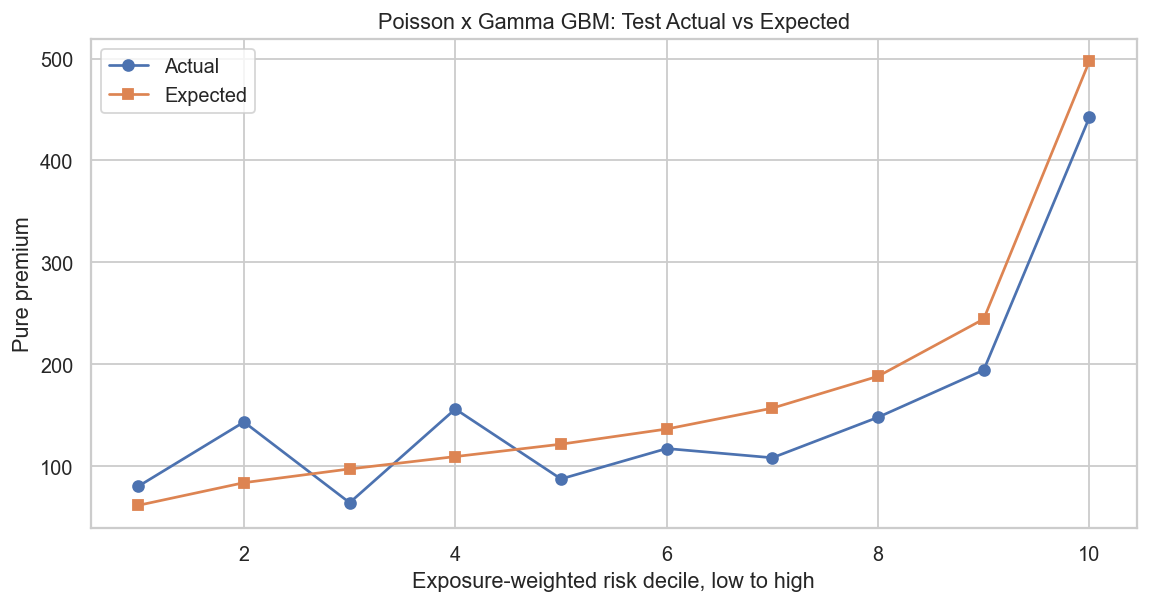

In [11]:
champion_lift = lift_table(test, champion_prefix)
print(f"Champion selected on validation: {champion_name}")
print(champion_lift.to_string(index=False))

fig, ax = plt.subplots(figsize=(9, 4.8))
ax.plot(champion_lift["decile"], champion_lift["actual_pure_premium"], marker="o", label="Actual")
ax.plot(champion_lift["decile"], champion_lift["expected_pure_premium"], marker="s", label="Expected")
ax.set(xlabel="Exposure-weighted risk decile, low to high", ylabel="Pure premium", title=f"{champion_name}: Test Actual vs Expected")
ax.legend()
fig.tight_layout()
plt.show()


In [12]:
def segment_relativity(data, group_col, prefix, minimum_exposure=500):
    expected_col = f"{prefix}_expected_loss"
    result = (
        data.groupby(group_col, observed=True)
        .agg(
            policies=("IDpol", "size"), exposure=("Exposure", "sum"),
            paid_claims=("PaidClaimNb", "sum"),
            actual_loss=("TotalClaimAmount", "sum"),
            expected_loss=(expected_col, "sum"),
        )
        .reset_index()
    )
    actual_portfolio_pp = result["actual_loss"].sum() / result["exposure"].sum()
    expected_portfolio_pp = result["expected_loss"].sum() / result["exposure"].sum()
    # Normalize segment loss costs to the portfolio average.
    result["observed_relativity"] = (result["actual_loss"] / result["exposure"]) / actual_portfolio_pp
    result["modeled_relativity"] = (result["expected_loss"] / result["exposure"]) / expected_portfolio_pp
    result["actual_to_expected"] = result["actual_loss"] / result["expected_loss"]
    # This is a review flag, not a formal actuarial credibility estimate.
    result["meets_minimum_exposure"] = result["exposure"] >= minimum_exposure
    return result

driver_age_relativity = segment_relativity(test, "DrivAgeBand", champion_prefix)
bonus_malus_relativity = segment_relativity(test, "BonusMalusBand", champion_prefix)

print("Driver age relativity")
print(driver_age_relativity.to_string(index=False))
print("\nBonus-malus relativity")
print(bonus_malus_relativity.to_string(index=False))


Driver age relativity
DrivAgeBand  policies    exposure  paid_claims    actual_loss  expected_loss  observed_relativity  modeled_relativity  actual_to_expected  meets_minimum_exposure
      18-24      6017  2,513.9525          411 1,164,369.3600 1,047,155.8204               3.0054              2.4550              1.1119                    True
      25-29     11572  5,102.7794          440   965,179.6700 1,061,563.1794               1.2274              1.2261              0.9092                    True
      30-39     33747 16,526.7687         1189 2,484,380.2200 2,535,248.5591               0.9754              0.9041              0.9799                    True
      40-49     33266 17,621.5319         1258 2,179,495.8400 2,982,184.7500               0.8026              0.9974              0.7308                    True
      50-59     28491 16,019.8200         1172 2,041,920.2600 2,527,867.4119               0.8271              0.9300              0.8078                    True
      

## 8. Paired Test-Set Variability

The bootstrap below uses identical policy resamples for both models. Its interval reflects sampling/process variability in the held-out portfolio; it does not include parameter-estimation uncertainty.


In [13]:
def paired_ae_bootstrap(data, n_boot=200, seed=RANDOM_STATE):
    rng = np.random.default_rng(seed)
    actual = data["TotalClaimAmount"].to_numpy()
    glm_expected = data["glm_expected_loss"].to_numpy()
    gbm_expected = data["gbm_expected_loss"].to_numpy()
    rows = []
    for _ in range(n_boot):
        # Reuse each sampled policy index for a paired model comparison.
        idx = rng.integers(0, len(data), size=len(data))
        actual_sum = actual[idx].sum()
        rows.append({
            "Poisson x Gamma GLM": actual_sum / glm_expected[idx].sum(),
            "Poisson x Gamma GBM": actual_sum / gbm_expected[idx].sum(),
        })
    boot = pd.DataFrame(rows)
    summary = boot.quantile([0.025, 0.50, 0.975]).T
    summary.columns = ["ci_025", "median", "ci_975"]
    return summary

ae_variability = paired_ae_bootstrap(test)
ae_variability


,ci_025,median,ci_975
Poisson x Gamma GLM,0.7779,0.8936,1.0332
Poisson x Gamma GBM,0.7924,0.9080,1.0523


## 9. Dynamic Actuarial Conclusion


In [14]:
# Pull the written conclusion directly from the evaluated result tables.
selected_test = model_comparison.loc[
    (model_comparison["split"] == "test")
    & (model_comparison["model"] == champion_name)
].iloc[0]
other_test = model_comparison.loc[
    (model_comparison["split"] == "test")
    & (model_comparison["model"] != champion_name)
].iloc[0]
selected_ci = ae_variability.loc[champion_name]

print(
    f"The {champion_name} was selected using validation pure-premium Tweedie deviance. "
    f"On the untouched test set, its Tweedie deviance is "
    f"{selected_test['pure_premium_tweedie_deviance']:.4f}, compared with "
    f"{other_test['pure_premium_tweedie_deviance']:.4f} for {other_test['model']}.\n"
    f"Test actual pure premium is {selected_test['actual_pure_premium']:.2f}; "
    f"expected pure premium is {selected_test['expected_pure_premium']:.2f}; "
    f"portfolio A/E is {selected_test['actual_to_expected']:.3f}. "
    f"The paired-bootstrap A/E interval is approximately "
    f"[{selected_ci['ci_025']:.3f}, {selected_ci['ci_975']:.3f}].\n"
    f"The model uses matched positive-payment frequency and positive-payment severity, "
    f"with a training-derived tail factor of {tail_factor:.3f}. This keeps the frequency-severity "
    f"identity aligned with paid loss. Final implementation would still require trend, expenses, "
    f"profit, reinsurance, regulatory review, and formal credibility treatment."
)


The Poisson x Gamma GBM was selected using validation pure-premium Tweedie deviance. On the untouched test set, its Tweedie deviance is 79.5800, compared with 81.9377 for Poisson x Gamma GLM.
Test actual pure premium is 154.11; expected pure premium is 169.67; portfolio A/E is 0.908. The paired-bootstrap A/E interval is approximately [0.792, 1.052].
The model uses matched positive-payment frequency and positive-payment severity, with a training-derived tail factor of 1.400. This keeps the frequency-severity identity aligned with paid loss. Final implementation would still require trend, expenses, profit, reinsurance, regulatory review, and formal credibility treatment.


## Limitations

- The public data contain positive payment records that do not all match the frequency table; unmatched records are quantified and excluded from this policy-level model.
- Random splitting is used because the dataset has no transaction date suitable for temporal validation.
- The tail factor is an aggregate provision, not a full excess-layer or extreme-value model.
- Minimum-exposure flags are reasonableness checks, not actuarial credibility estimates.
- Pure premium excludes trend, expenses, profit, taxes, reinsurance, and implementation constraints.
